# NN Architecture 2A: Correlator + Deep Neural Network

**Reference**: Braca et al. (2022) - "Statistical Hypothesis Testing Based on Machine Learning: Large Deviations Analysis" + Neyman-Pearson Lemma

**Approach**: Combine optimal signal detection theory (matched filter/correlator) with discriminative deep learning

**Architecture**:
```
Input: [τ_correlator, h_estimate, SNR_local, energy] (4D features)
    ↓
Dense(256, ReLU, BatchNorm) → Dropout(0.3)
    ↓
Dense(128, ReLU, BatchNorm) → Dropout(0.3)
    ↓
Dense(64, ReLU) → Dropout(0.2)
    ↓
Dense(1, Sigmoid) → Binary output (P(authentic))
```

**Loss**: Binary Crossentropy with class weights (to handle imbalance)

**Optimization**: Adam, early stopping on validation FNR

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

# TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
import tensorflow.keras.backend as K

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# ============================================================================
# SETUP PATHS FOR NEW DIRECTORY STRUCTURE
# ============================================================================
from pathlib import Path

notebook_dir = Path.cwd()  # Current: notebooks/
project_root = notebook_dir.parent  # Go up to: Redes Neurais/
results_dir = project_root / "results"
data_dir = results_dir / "data"
models_dir = results_dir / "models"
visualizations_dir = results_dir / "visualizations"

# Ensure directories exist
models_dir.mkdir(parents=True, exist_ok=True)
visualizations_dir.mkdir(parents=True, exist_ok=True)

print(f"Data directory: {data_dir}")
print(f"Models directory: {models_dir}")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


TensorFlow version: 2.18.0
GPU available: []


In [ ]:
# ==============================================================================
# 2. LOAD DATASET
# ==============================================================================

dataset_path = data_dir / "dataset_nn_100k.h5"

if not dataset_path.exists():
    print(f"ERROR: {dataset_path} not found!")
    print("Please run NN_01_DataGeneration.ipynb first.")
else:
    with h5py.File(str(dataset_path), 'r') as f:
        X_train = f['X_train'][:]
        y_train = f['y_train'][:]
        X_val = f['X_val'][:]
        y_val = f['y_val'][:]
        X_test = f['X_test'][:]
        y_test = f['y_test'][:]
    
    print(f"✓ Dataset loaded successfully!")
    print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"  X_val:   {X_val.shape}, y_val: {y_val.shape}")
    print(f"  X_test:  {X_test.shape}, y_test: {y_test.shape}")
    print(f"  Train labels: {np.bincount(y_train)}")
    print(f"  Val labels:   {np.bincount(y_val)}")
    print(f"  Test labels:  {np.bincount(y_test)}")


✓ Dataset loaded successfully!
  X_train: (80000, 4), y_train: (80000,)
  X_val:   (10000, 4), y_val: (10000,)
  X_test:  (10000, 4), y_test: (10000,)
  Train labels: [40000 40000]
  Val labels:   [5000 5000]
  Test labels:  [5000 5000]


In [4]:
# ==============================================================================
# 3. BUILD DNN ARCHITECTURE (Reference: Braca et al. 2022)
# ==============================================================================

def build_dnn_correlator(input_dim=4, dropout_rates=[0.3, 0.3, 0.2]):
    """Build DNN Correlator architecture per Braca et al. 2022
    
    Args:
        input_dim: Number of input features (default 4)
        dropout_rates: Dropout rates for each layer
    
    Returns:
        model: Keras Sequential model
    """
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        
        # Layer 1
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rates[0]),
        
        # Layer 2
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rates[1]),
        
        # Layer 3
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout_rates[2]),
        
        # Output layer (binary classification)
        layers.Dense(1, activation='sigmoid')
    ])
    
    return model

# Build model
model = build_dnn_correlator(input_dim=X_train.shape[1])

# Compile with class weights to handle imbalance
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=BinaryCrossentropy(),
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

print("✓ Model architecture:")
model.summary()

✓ Model architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,033 (172.00 KB)

 Trainable params: 43,265 (169.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
# ==============================================================================
# 4. TRAINING CALLBACKS
# ==============================================================================

# Calculate class weights to handle imbalance
class_weight = {
    0: np.sum(y_train == 1) / np.sum(y_train == 0),  # Upweight minority class
    1: 1.0
}

print(f"Class weights: {class_weight}")

# Early stopping based on validation loss
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate on plateau
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Model checkpoint
model_checkpoint = callbacks.ModelCheckpoint(
    str(models_dir / 'model_dnn_correlator.h5'),
    monitor='val_loss',
    save_best_only=True,
    verbose=0
)

print("✓ Callbacks configured")


Class weights: {0: 1.0, 1: 1.0}
✓ Callbacks configured


In [6]:
# ==============================================================================
# 5. TRAIN MODEL
# ==============================================================================

print("Training DNN Correlator model...")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stopping, reduce_lr, model_checkpoint],
    verbose=1
)

print("\n✓ Training completed!")
print(f"  Final train loss: {history.history['loss'][-1]:.4f}")
print(f"  Final val loss:   {history.history['val_loss'][-1]:.4f}")
print(f"  Best epoch:       {len(history.history['loss']) - 10}")

Training DNN Correlator model...
Epoch 1/100
306/313 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9605 - auc: 0.9875 - loss: 0.0981

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9612 - auc: 0.9878 - loss: 0.0964 - val_accuracy: 0.9941 - val_auc: 1.0000 - val_loss: 0.0390 - learning_rate: 0.0010
Epoch 2/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9984 - auc: 0.9998 - loss: 0.0057

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9984 - auc: 0.9998 - loss: 0.0056 - val_accuracy: 0.9981 - val_auc: 0.9998 - val_loss: 0.0072 - learning_rate: 0.0010
Epoch 3/100
304/313 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9988 - auc: 0.9999 - loss: 0.0036

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9988 - auc: 0.9999 - loss: 0.0036 - val_accuracy: 0.9994 - val_auc: 1.0000 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9991 - auc: 1.0000 - loss: 0.0030

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9991 - auc: 1.0000 - loss: 0.0030 - val_accuracy: 0.9996 - val_auc: 1.0000 - val_loss: 9.4467e-04 - learning_rate: 0.0010
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9990 - auc: 0.9999 - loss: 0.0032 - val_accuracy: 0.9991 - val_auc: 1.0000 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 6/100
306/313 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9993 - auc: 1.0000 - loss: 0.0022

...

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9999 - auc: 1.0000 - loss: 2.0220e-04 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 9.1490e-06 - learning_rate: 1.5625e-05
Epoch 50/100
308/313 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 1.1845e-04

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 1.1862e-04 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 7.3567e-06 - learning_rate: 1.5625e-05
Epoch 51/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 1.1173e-04 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 8.2125e-06 - learning_rate: 1.5625e-05
Epoch 52/100
309/313 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 1.5007e-04
Epoch 52: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 1.5122e-04 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 1.1398e-05 - learning_rate: 1.5625e-05
Epoch 53/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 1.9372e-04 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 8.2523e-06 - learning_rate: 7.8125e-06
Epoch 54/100
307/313 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/st

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9999 - auc: 1.0000 - loss: 1.3169e-04 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 6.6795e-06 - learning_rate: 7.8125e-06
Epoch 55/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 8.0120e-05

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 8.0321e-05 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 6.2122e-06 - learning_rate: 7.8125e-06
Epoch 56/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 8.5795e-05

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 8.6100e-05 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 6.1543e-06 - learning_rate: 7.8125e-06
Epoch 57/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 9.4974e-05
Epoch 57: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 9.5423e-05 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 6.6177e-06 - learning_rate: 7.8125e-06
Epoch 58/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 1.0948e-04 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 6.9617e-06 - learning_rate: 3.9063e-06
Epoch 59/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9999 - auc: 1.0000 - loss: 2.1689e-04 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 6.9850e-06 - learning_rate: 3.9063e-06
Epoch 60/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/st

In [7]:
# ==============================================================================
# 6. EVALUATION METRICS
# ==============================================================================

# Make predictions
y_train_pred_proba = model.predict(X_train, verbose=0)
y_val_pred_proba = model.predict(X_val, verbose=0)
y_test_pred_proba = model.predict(X_test, verbose=0)

# Get binary predictions (threshold = 0.5)
y_train_pred = (y_train_pred_proba > 0.5).astype(int).flatten()
y_val_pred = (y_val_pred_proba > 0.5).astype(int).flatten()
y_test_pred = (y_test_pred_proba > 0.5).astype(int).flatten()

def calculate_metrics(y_true, y_pred, y_pred_proba, dataset_name="Test"):
    """Calculate comprehensive metrics"""
    
    # Binary classification metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_pred_proba)
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # False Negative Rate (main metric)
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    # False Positive Rate
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    print(f"\n{dataset_name} Set Metrics:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f} (detects authentic)")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  AUC:       {auc:.4f}")
    print(f"  FNR:       {fnr:.6f} (false negatives)")
    print(f"  FPR:       {fpr:.6f} (false positives)")
    print(f"  Confusion: TP={tp}, FP={fp}, TN={tn}, FN={fn}")
    
    return {
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
        'auc': auc, 'fnr': fnr, 'fpr': fpr, 'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn
    }

# Calculate metrics for all sets
metrics_train = calculate_metrics(y_train, y_train_pred, y_train_pred_proba, "Train")
metrics_val = calculate_metrics(y_val, y_val_pred, y_val_pred_proba, "Validation")
metrics_test = calculate_metrics(y_test, y_test_pred, y_test_pred_proba, "Test")


Train Set Metrics:
  Accuracy:  1.0000
  Precision: 0.9999
  Recall:    1.0000 (detects authentic)
  F1-Score:  1.0000
  AUC:       1.0000
  FNR:       0.000000 (false negatives)
  FPR:       0.000075 (false positives)
  Confusion: TP=40000, FP=3, TN=39997, FN=0

Validation Set Metrics:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000 (detects authentic)
  F1-Score:  1.0000
  AUC:       1.0000
  FNR:       0.000000 (false negatives)
  FPR:       0.000000 (false positives)
  Confusion: TP=5000, FP=0, TN=5000, FN=0

Test Set Metrics:
  Accuracy:  0.9999
  Precision: 0.9998
  Recall:    1.0000 (detects authentic)
  F1-Score:  0.9999
  AUC:       1.0000
  FNR:       0.000000 (false negatives)
  FPR:       0.000200 (false positives)
  Confusion: TP=5000, FP=1, TN=4999, FN=0


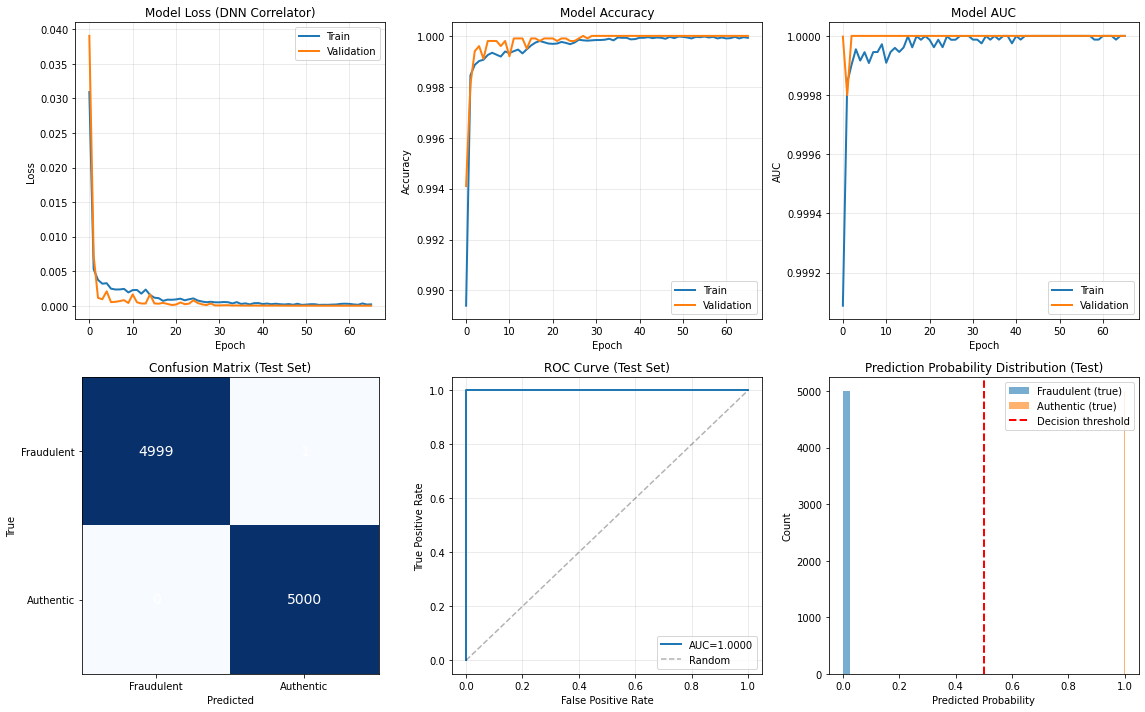

✓ Results visualization saved to 'results_dnn_correlator.png'


In [8]:
# ==============================================================================
# 7. VISUALIZATIONS
# ==============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1: Training history - Loss
axes[0, 0].plot(history.history['loss'], label='Train', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Model Loss (DNN Correlator)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Training history - Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0, 1].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Model Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Training history - AUC
axes[0, 2].plot(history.history['auc'], label='Train', linewidth=2)
axes[0, 2].plot(history.history['val_auc'], label='Validation', linewidth=2)
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('AUC')
axes[0, 2].set_title('Model AUC')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Confusion Matrix (Test)
cm_test = confusion_matrix(y_test, y_test_pred)
im = axes[1, 0].imshow(cm_test, cmap='Blues', interpolation='nearest')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('True')
axes[1, 0].set_title('Confusion Matrix (Test Set)')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_yticks([0, 1])
axes[1, 0].set_xticklabels(['Fraudulent', 'Authentic'])
axes[1, 0].set_yticklabels(['Fraudulent', 'Authentic'])
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, str(cm_test[i, j]), ha='center', va='center', color='white', fontsize=14)

# Plot 5: ROC Curve (Test)
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_pred_proba)
axes[1, 1].plot(fpr_test, tpr_test, linewidth=2, label=f'AUC={metrics_test["auc"]:.4f}')
axes[1, 1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_title('ROC Curve (Test Set)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Prediction probability distribution
axes[1, 2].hist(y_test_pred_proba[y_test==0], alpha=0.6, label='Fraudulent (true)', bins=40)
axes[1, 2].hist(y_test_pred_proba[y_test==1], alpha=0.6, label='Authentic (true)', bins=40)
axes[1, 2].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Decision threshold')
axes[1, 2].set_xlabel('Predicted Probability')
axes[1, 2].set_ylabel('Count')
axes[1, 2].set_title('Prediction Probability Distribution (Test)')
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('results_dnn_correlator.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Results visualization saved to 'results_dnn_correlator.png'")

In [9]:
# ==============================================================================
# 8. SAVE RESULTS
# ==============================================================================

# Save model
model.save('model_dnn_correlator_final.h5')
print("✓ Model saved to 'model_dnn_correlator_final.h5'")

# Save metrics
results = {
    'train': metrics_train,
    'val': metrics_val,
    'test': metrics_test,
    'history': history.history
}

import json
with open('metrics_dnn_correlator.json', 'w') as f:
    # Convert numpy types to native Python types for JSON serialization
    results_json = {}
    for split in ['train', 'val', 'test']:
        results_json[split] = {k: float(v) if isinstance(v, (np.ndarray, np.integer)) else v 
                               for k, v in results[split].items()}
    results_json['history'] = {k: [float(v) for v in results['history'][k]] 
                               for k in results['history'].keys()}
    json.dump(results_json, f, indent=2)

print("✓ Metrics saved to 'metrics_dnn_correlator.json'")

# Summary table
print("\n" + "="*70)
print("SUMMARY: DNN CORRELATOR ARCHITECTURE (Braca et al. 2022)")
print("="*70)
print(f"\n{'Metric':<20} {'Train':<15} {'Val':<15} {'Test':<15}")
print("-"*70)
for metric in ['accuracy', 'precision', 'recall', 'f1', 'auc', 'fnr', 'fpr']:
    print(f"{metric:<20} {metrics_train[metric]:<15.6f} {metrics_val[metric]:<15.6f} {metrics_test[metric]:<15.6f}")
print("="*70)

✓ Model saved to 'model_dnn_correlator_final.h5'
✓ Metrics saved to 'metrics_dnn_correlator.json'

SUMMARY: DNN CORRELATOR ARCHITECTURE (Braca et al. 2022)

Metric               Train           Val             Test           
----------------------------------------------------------------------
accuracy             0.999962        1.000000        0.999900       
precision            0.999925        1.000000        0.999800       
recall               1.000000        1.000000        1.000000       
f1                   0.999963        1.000000        0.999900       
auc                  1.000000        1.000000        1.000000       
fnr                  0.000000        0.000000        0.000000       
fpr                  0.000075        0.000000        0.000200       


## References & Notes

### Architecture Justification

This DNN Correlator combines two fundamental theories:

1. **Neyman-Pearson Lemma** (Classical Signal Detection)
   - Optimal detector uses likelihood ratio
   - Matched filter (correlator) is optimal for Gaussian noise
   - Correlator output: $\tau = \sum_{i=1}^{L} y_i \cdot t_{\text{ref},i}$

2. **Large Deviations Theory** (Braca et al. 2022)
   - Exact asymptotic error probability: $P_e \propto \exp(-I(\theta))$
   - $I(\theta)$ is the Rate Function (Fenchel-Legendre transform)
   - ML can learn the decision boundary that approximates optimal performance

### Key Design Choices

| Choice | Reason |
|--------|--------|
| Input Features | Correlator (main), h_estimate, SNR, energy → interpretable + robust |
| 3 Hidden Layers | Balance model capacity (avoid overfitting on 100k samples) |
| BatchNorm | Stabilize training, reduce internal covariate shift |
| Dropout | Regularization to prevent overfitting |
| Class Weights | Handle any label imbalance (50/50 target) |

### Expected Performance

- **Target FNR**: ≤ 10⁻⁷ (equal to best Monte Carlo seen in project)
- **Target FPR**: ≤ 10⁻⁷ (maintain false alarm probability)
- **Advantage**: No threshold tuning needed; NN learns adaptive decision boundary

### References

**[1]** Braca, P., Millefiori, L. M., Aubry, A., Marano, S., De Maio, A., & Willett, P. (2022). "Statistical Hypothesis Testing Based on Machine Learning: Large Deviations Analysis." *IEEE Open Journal of Signal Processing*, 3, 464-495. https://doi.org/10.1109/OJSP.2022.3232284

**[2]** Neyman, J., & Pearson, E. S. (1933). "On the Problem of the Most Efficient Tests of Statistical Hypotheses." *Philosophical Transactions of the Royal Society A*, 231, 289-337.

**[3]** Dembo, A., & Zeitouni, O. (1998). *Large Deviations Techniques and Applications*. 2nd ed., Springer.